In [1]:
import re
import nltk
import numpy as np
import pandas as pd

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Embedding, Flatten, LeakyReLU

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score


In [2]:
nltk.download('stopwords')
nltk.download('punkt')
nltk.download('wordnet')


[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/ssgmcollege/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt to
[nltk_data]     /Users/ssgmcollege/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     /Users/ssgmcollege/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [3]:
df = pd.read_csv(
    "IMDB_Dataset.csv",
    engine="python",
    encoding="latin-1",
    on_bad_lines="skip"
)


In [4]:
df = df[['review', 'sentiment']]          # ensure only 2 columns
df['review'] = df['review'].astype(str)
df['sentiment'] = df['sentiment'].astype(str).str.lower().str.strip()

df = df[df['sentiment'].isin(['positive', 'negative'])]
df['sentiment'] = df['sentiment'].map({'positive': 1, 'negative': 0})

print("Rows after basic cleaning:", len(df))


Rows after basic cleaning: 49639


In [5]:
from sklearn.model_selection import train_test_split
X = df['review']
y = df['sentiment']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train size:", len(X_train))
print("Test size:", len(X_test))


Train size: 39711
Test size: 9928


In [6]:
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def preprocess_text(text):
    text = text.lower()
    text = re.sub(r'[^a-z\s]', ' ', text)
    tokens = nltk.word_tokenize(text)
    tokens = [lemmatizer.lemmatize(w) for w in tokens if w not in stop_words]
    return " ".join(tokens)



In [7]:
X_train_clean = X_train.apply(preprocess_text)
X_test_clean = X_test.apply(preprocess_text)


In [8]:
train_mask = X_train_clean.str.len() > 0
test_mask = X_test_clean.str.len() > 0

X_train_clean = X_train_clean[train_mask]
y_train = y_train[train_mask]

X_test_clean = X_test_clean[test_mask]
y_test = y_test[test_mask]

print("Train after preprocessing:", len(X_train_clean))
print("Test after preprocessing:", len(X_test_clean))


Train after preprocessing: 39711
Test after preprocessing: 9928


In [9]:
vocab_size = 10000
max_length = 200

tokenizer = Tokenizer(num_words=vocab_size)
tokenizer.fit_on_texts(X_train_clean)

X_train_seq = tokenizer.texts_to_sequences(X_train_clean)
X_test_seq = tokenizer.texts_to_sequences(X_test_clean)

X_train_pad = pad_sequences(X_train_seq, maxlen=max_length)
X_test_pad = pad_sequences(X_test_seq, maxlen=max_length)


In [10]:
def build_model(activation):
    model = Sequential()
    model.add(Embedding(vocab_size, 128, input_length=max_length))
    model.add(Flatten())

    if activation == "leaky_relu":
        model.add(Dense(64))
        model.add(LeakyReLU(0.1))
        model.add(Dense(32))
        model.add(LeakyReLU(0.1))
    else:
        model.add(Dense(64, activation=activation))
        model.add(Dense(32, activation=activation))

    model.add(Dense(1, activation='sigmoid'))

    model.compile(
        optimizer='adam',
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    return model



In [ ]:
activations = ["relu", "tanh", "sigmoid", "leaky_relu"]
results = {}

for act in activations:
    model = build_model(act)

    model.fit(
        X_train_pad, y_train,
        epochs=10,
        batch_size=64,
        validation_split=0.2,
        verbose=0
    )

    y_pred = (model.predict(X_test_pad) >= 0.5).astype(int)

    results[act] = {
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1": f1_score(y_test, y_pred)
    }


/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(
2026-04-15 13:21:15.347012: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M2
2026-04-15 13:21:15.348114: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 8.00 GB
2026-04-15 13:21:15.348123: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 2.67 GB
2026-04-15 13:21:15.348947: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-04-15 13:21:15.349730: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus 

In [73]:
print("\nACTIVATION FUNCTION COMPARISON\n")

print(f"{'Activation':12s} {'Accuracy':10s} {'Precision':10s} {'Recall':10s} {'F1-Score':10s}")
print("-" * 65)

for act, m in results.items():
    print(f"{act.upper():12s} "
          f"{m['Accuracy']:.4f}     "
          f"{m['Precision']:.4f}     "
          f"{m['Recall']:.4f}     "
          f"{m['F1']:.4f}")



ACTIVATION FUNCTION COMPARISON

Activation   Accuracy   Precision  Recall     F1-Score  
-----------------------------------------------------------------
RELU         0.8674     0.8575     0.8810     0.8691
TANH         0.8481     0.8401     0.8599     0.8499
SIGMOID      0.8578     0.8955     0.8101     0.8506
LEAKY_RELU   0.8578     0.8235     0.9107     0.8649


In [30]:
import pandas as pd
import matplotlib.pyplot  as plt


results_df = pd.DataFrame(results).T
results_df = results_df[['Accuracy', 'Precision', 'Recall', 'F1']]


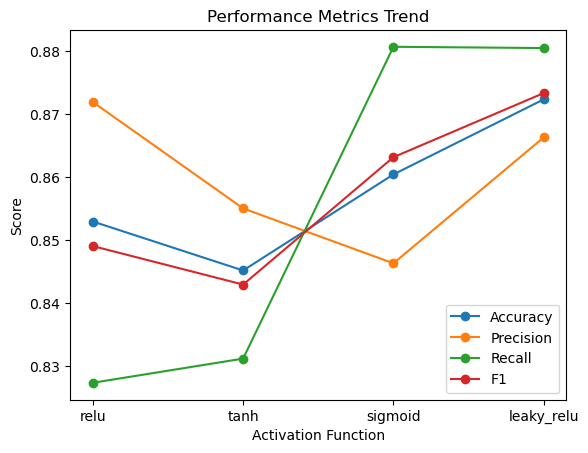

In [31]:
plt.figure()

for metric in results_df.columns:
    plt.plot(results_df.index, results_df[metric], marker='o', label=metric)

plt.xlabel("Activation Function")
plt.ylabel("Score")
plt.title("Performance Metrics Trend")
plt.legend()
plt.show()


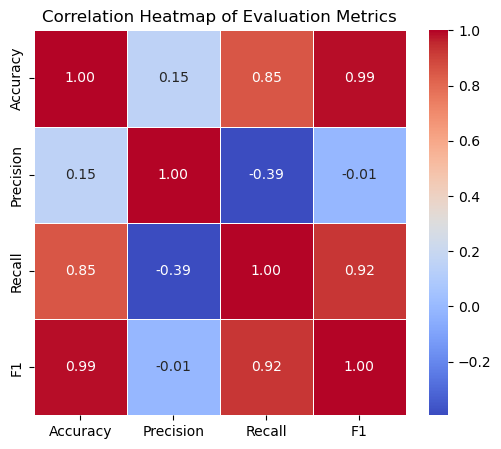

In [32]:
import seaborn as sns
import matplotlib.pyplot as plt
corr_matrix = results_df.corr()
plt.figure(figsize=(6, 5))
sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5
)

plt.title("Correlation Heatmap of Evaluation Metrics")
plt.show()
